# Méthodes Quantitatives en Histoire — Visualisation de données
### Louis Maritaud
### louis.maritaud@unilim.fr



## Objectifs pédagogiques

- Comprendre la logique **Figure / Axes** de Matplotlib (la "page" et le "graphique" à l'intérieur)
- Tracer des courbes d'évolution dans le temps (démographie d'une ou plusieurs villes)
- Comparer des villes avec des diagrammes en barres et des nuages de points
- Utiliser **Seaborn** pour explorer rapidement un grand tableau de données
- Regrouper des données chiffrées en catégories utiles pour l'historien·ne, avec `pd.cut()`
- Choisir le bon type de graphique selon la question posée : boxplot (comparer des distributions), histogramme (voir une distribution globale), heatmap (croiser deux catégories), graphique interactif (explorer librement)

**Le fichier de données** : `pop_hist.csv` — une ligne par commune française, avec sa population à différentes dates de recensement (colonnes `PTOT1876`, ..., `PMUN2023`). 

## Premiers graphiques avec Matplotlib

### L'architecture Figure / Axes

Pour tracer un graphique avec Matplotlib, on crée toujours deux objets :

- la **Figure** (`fig`) : la feuille blanche, l'espace global qui peut contenir un ou plusieurs graphiques ;
- l'**Axe** (`ax`) : le graphique lui-même (les courbes, les axes X et Y, le titre...).

On les crée en une seule ligne :

```python
fig, ax = plt.subplots()
```

Ensuite, tout ce qu'on ajoute au graphique se fait via `ax` : `ax.plot(...)`, `ax.set_title(...)`, etc.

In [28]:
# On importe les bibliothèques dont on va avoir besoin
import pandas as pd
import matplotlib.pyplot as plt

# On charge le tableau de données (une ligne par commune)
df = pd.read_csv("DATA/pop_hist.csv", dtype=str)

print(f"Le tableau contient {len(df)} communes.")
df.head()

Le tableau contient 34877 communes.


,CODGEO,REG,DEP,LIBGEO,PMUN2023,PMUN2022,PMUN2021,PMUN2020,PMUN2019,PMUN2018,...,PTOT1926,PTOT1921,PTOT1911,PTOT1906,PTOT1901,PTOT1896,PTOT1891,PTOT1886,PTOT1881,PTOT1876
0,01001,84,01,L'Abergement-Clémenciat,860,859,832,806,779,771,...,543,566,560,629,637,572,594,622,605,604
1,01002,84,01,L'Abergement-de-Varey,270,273,267,262,256,253,...,253,256,291,323,357,391,421,486,490,484
2,01004,84,01,Ambérieu-en-Bugey,15 934,15 554,14 854,14 288,14 134,14 204,...,5 705,4 796,4 334,4 100,4 023,3 548,3 635,3 618,3 396,3 427
3,01005,84,01,Ambérieux-en-Dombes,1 906,1 917,1 897,1 782,1 751,1 720,...,690,698,805,805,835,852,862,882,879,848
4,01006,84,01,Ambléon,115,114,113,113,112,112,...,161,150,159,193,200,206,200,200,213,191


### Une première courbe : l'évolution de Limoges

Les colonnes de population (par exemple `PTOT1876`) sont importées comme du **texte**, parce que les grands nombres contiennent des espaces (`59 672`). Il faut donc :

1. sélectionner la ligne de la ville qui nous intéresse ;
2. retirer les espaces dans les nombres ;
3. convertir le texte en nombre entier.

In [29]:
# On récupère la ligne correspondant à Limoges
limoges = df[df["LIBGEO"] == "Limoges"].iloc[0]

# On choisit quelques années-jalons et les colonnes correspondantes
annees = [1876, 1911, 1954, 1990, 2011, 2023]
colonnes = ["PTOT1876", "PTOT1911", "PTOT1954", "PSDC1990", "PMUN2011", "PMUN2023"]

# On nettoie chaque valeur : on retire les espaces puis on convertit en entier
populations = [int(limoges[col].replace("\u202f", "").replace(" ", "")) for col in colonnes]

print(annees)
print(populations)

[1876, 1911, 1954, 1990, 2011, 2023]
[59672, 92973, 106851, 133486, 137758, 129937]


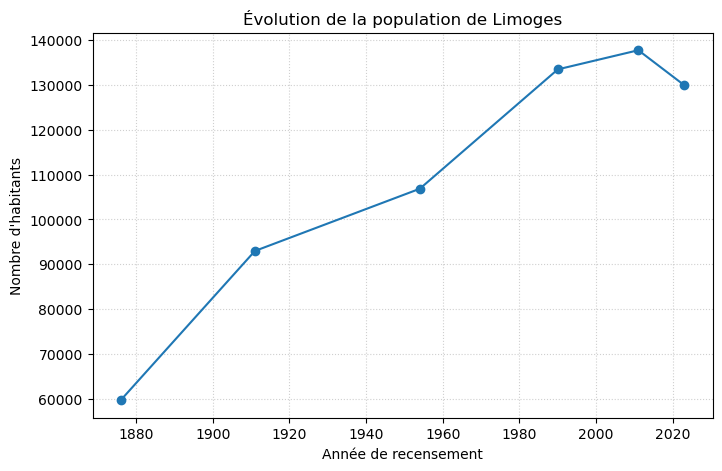

In [30]:
# 1. On crée la figure et l'axe
fig, ax = plt.subplots(figsize=(8, 5))

# 2. On trace la courbe : ax.plot(x, y)
ax.plot(annees, populations, marker="o")

# 3. On habille le graphique
ax.set_title("Évolution de la population de Limoges")
ax.set_xlabel("Année de recensement")
ax.set_ylabel("Nombre d'habitants")
ax.grid(True, linestyle=":", alpha=0.6)

plt.show()

### Comparer deux villes : Limoges et Bordeaux

Pour comparer deux courbes sur le même graphique, il suffit d'appeler `ax.plot()` une deuxième fois, avec `label=` pour que la légende s'affiche correctement.

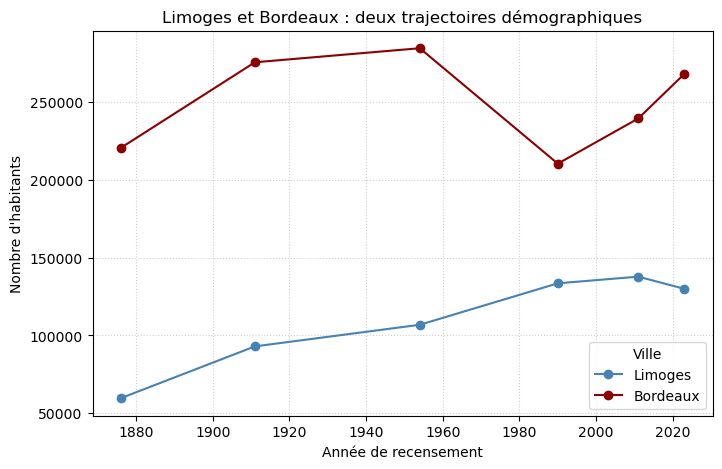

In [31]:
# On refait la même opération de nettoyage, mais pour Bordeaux
bordeaux = df[df["LIBGEO"] == "Bordeaux"].iloc[0]
populations_bordeaux = [int(bordeaux[col].replace("\u202f", "").replace(" ", "")) for col in colonnes]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(annees, populations, marker="o", color="#4682b4", label="Limoges")
ax.plot(annees, populations_bordeaux, marker="o", color="#8b0000", label="Bordeaux")

ax.set_title("Limoges et Bordeaux : deux trajectoires démographiques")
ax.set_xlabel("Année de recensement")
ax.set_ylabel("Nombre d'habitants")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(title="Ville")

plt.show()

### Exercice 1

Reprenez le code de la partie 1.3 pour comparer **deux autres communes de votre choix**, par exemple `"Tulle"` et `"Guéret"` (ou toute autre commune présente dans `df["LIBGEO"]`).

Consignes :
- une courbe **rouge** pour la première ville, une courbe **bleue** pour la seconde ;
- un marqueur sur chaque point (`marker="o"`) ;
- une grille en arrière-plan ;
- un titre, des axes légendés, et une légende.

*Astuce : vérifiez d'abord que le nom de la ville existe bien dans le tableau avec `df[df["LIBGEO"] == "NomDeLaVille"]`.*

In [32]:
# Votre code ici

## Aller plus vite avec un tableau "long" et Seaborn

### Le problème du format "large"

Dans `df`, chaque **année est une colonne différente** (`PTOT1876`, `PTOT1911`, ...). C'est pratique à lire, mais pénible à tracer si l'on veut **toutes** les années sans les sélectionner une par une.

La solution : transformer le tableau du format **large** (une colonne par année) au format **long** (une ligne par année), avec `pd.melt()`.

Petit exemple pour comprendre, sur un mini-tableau :

In [33]:
exemple_large = pd.DataFrame({
    "Ville": ["Limoges", "Bordeaux"],
    "1900": [80000, 250000],
    "2000": [130000, 210000],
})
print("Format large :")
display(exemple_large)

exemple_long = exemple_large.melt(id_vars="Ville", var_name="Annee", value_name="Population")
print("Format long, après melt() :")
display(exemple_long)

Format large :


,Ville,1900,2000
0,Limoges,80000,130000
1,Bordeaux,250000,210000


Format long, après melt() :


,Ville,Annee,Population
0,Limoges,1900,80000
1,Bordeaux,1900,250000
2,Limoges,2000,130000
3,Bordeaux,2000,210000


### Appliquer `melt()` à nos données

On applique la même idée à Limoges et Bordeaux, avec toutes leurs colonnes d'années.

In [34]:
# On garde seulement Limoges et Bordeaux
villes = df[df["LIBGEO"].isin(["Limoges", "Bordeaux"])].copy()

# Les colonnes d'identité (à ne pas fusionner) et les colonnes d'années (à fusionner)
colonnes_identite = ["CODGEO", "REG", "DEP", "LIBGEO"]
colonnes_annees = [c for c in villes.columns if c not in colonnes_identite]

df_long = villes.melt(
    id_vars=colonnes_identite,
    value_vars=colonnes_annees,
    var_name="Annee_brute",   # ex: "PTOT1876"
    value_name="Population",
)

# "PTOT1876" -> "1876" : on retire les lettres du début pour ne garder que l'année
df_long["Annee"] = (
    df_long["Annee_brute"]
    .str.replace("PTOT", "", regex=False)
    .str.replace("PSDC", "", regex=False)
    .str.replace("PMUN", "", regex=False)
    .astype(int)
)

# Nettoyage des nombres (espaces) comme avant, mais sur toute la colonne d'un coup
df_long["Population"] = (
    df_long["Population"]
    .str.replace(r"\s+", "", regex=True)
    .astype(int)
)

df_long = df_long[["LIBGEO", "Annee", "Population"]].sort_values(["LIBGEO", "Annee"])
df_long.head()

,LIBGEO,Annee,Population
72,Bordeaux,1876,220446
70,Bordeaux,1881,227736
68,Bordeaux,1886,248545
66,Bordeaux,1891,261085
64,Bordeaux,1896,267369


### Le même graphique qu'au dessus mais en 3 lignes avec Seaborn

Une fois les données au format long, Seaborn se charge tout seul des couleurs et de la légende grâce au paramètre `hue`.

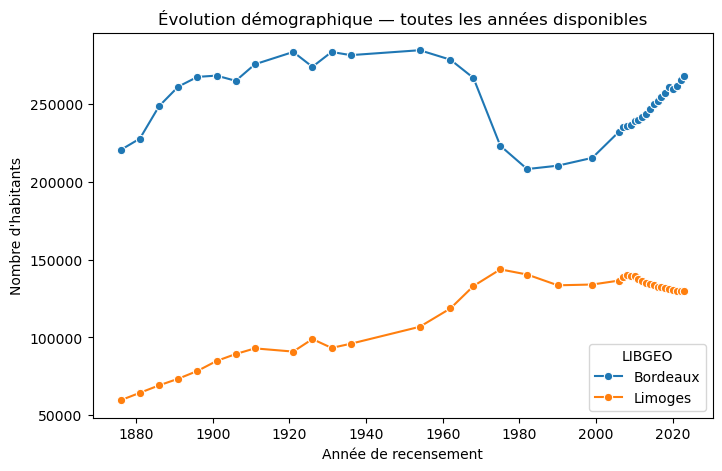

In [35]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(data=df_long, x="Annee", y="Population", hue="LIBGEO", marker="o", ax=ax)

ax.set_title("Évolution démographique — toutes les années disponibles")
ax.set_xlabel("Année de recensement")
ax.set_ylabel("Nombre d'habitants")

plt.show()

### Exercice 2

À partir de `df_long`, réalisez un **diagramme en barres** (`ax.bar`) comparant la population de Limoges et de Bordeaux pour **une seule année de votre choix** (par exemple 2023).

Consignes :
- filtrez `df_long` pour ne garder que l'année choisie ;
- une barre par ville, avec une couleur différente ;
- un titre et des axes légendés.

In [36]:
# Votre code ici

##  Plusieurs graphiques côte à côte (subplots)

On peut aussi placer **deux graphiques dans une seule figure**, en précisant le nombre de lignes et de colonnes dans `plt.subplots(1, 2)`. `ax` devient alors une liste : `ax[0]` pour le graphique de gauche, `ax[1]` pour celui de droite.

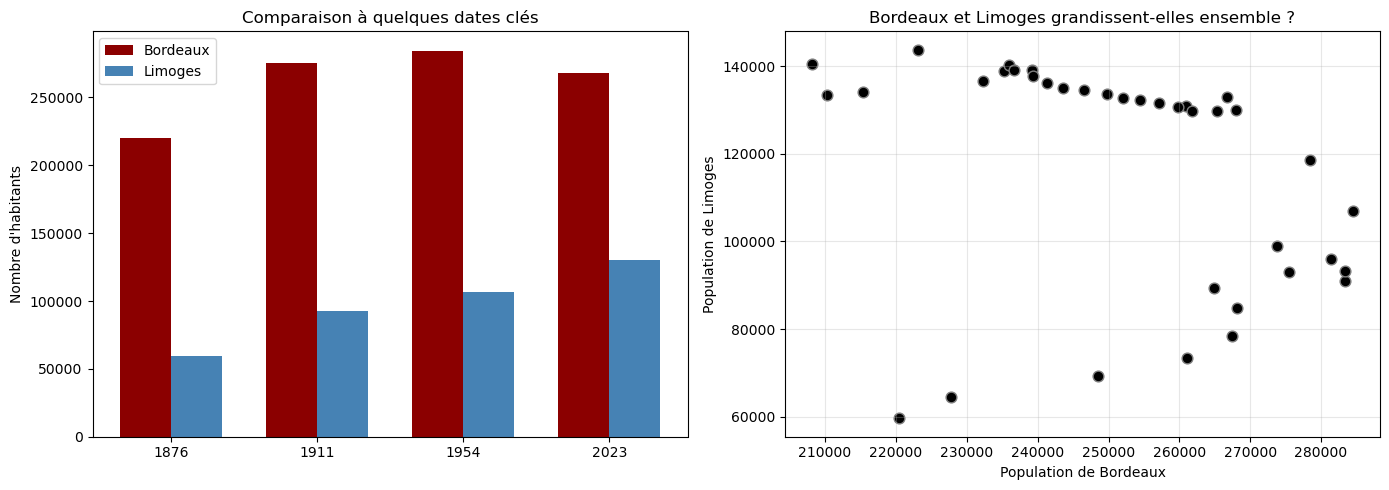

In [37]:
import numpy as np

# --- Données pour le graphique de gauche : quelques jalons chronologiques ---
annees_selectionnees = [1876, 1911, 1954, 2023]
df_jalons = df_long[df_long["Annee"].isin(annees_selectionnees)]

pop_bordeaux = df_jalons[df_jalons["LIBGEO"] == "Bordeaux"].sort_values("Annee")["Population"]
pop_limoges = df_jalons[df_jalons["LIBGEO"] == "Limoges"].sort_values("Annee")["Population"]

# --- Données pour le graphique de droite : toutes les années communes, en colonnes ---
df_pivot = df_long.pivot(index="Annee", columns="LIBGEO", values="Population").dropna()

# --- Construction de la figure : 1 ligne, 2 colonnes ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Graphique de gauche : barres comparatives
x = np.arange(len(annees_selectionnees))
largeur = 0.35
ax[0].bar(x - largeur / 2, pop_bordeaux, largeur, label="Bordeaux", color="#8b0000")
ax[0].bar(x + largeur / 2, pop_limoges, largeur, label="Limoges", color="#4682b4")
ax[0].set_xticks(x)
ax[0].set_xticklabels(annees_selectionnees)
ax[0].set_title("Comparaison à quelques dates clés")
ax[0].set_ylabel("Nombre d'habitants")
ax[0].legend()

# Graphique de droite : nuage de points (une ville par axe)
ax[1].scatter(df_pivot["Bordeaux"], df_pivot["Limoges"], color="black", s=60, edgecolor="grey")
ax[1].set_title("Bordeaux et Limoges grandissent-elles ensemble ?")
ax[1].set_xlabel("Population de Bordeaux")
ax[1].set_ylabel("Population de Limoges")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Regrouper des données en catégories avec `pd.cut()`

En histoire, on préfère souvent travailler avec des **catégories** (petite ville / grande ville, jeune / âgé...) plutôt qu'avec des nombres bruts. La méthode `pd.cut()` permet de transformer une variable continue en catégories, à partir de seuils que l'on choisit.

Petit exemple pour comprendre :

In [38]:
exemple = pd.DataFrame({"age": [5, 15, 40, 70]})

exemple["categorie"] = pd.cut(
    exemple["age"],
    bins=[0, 12, 18, 65, 120],
    labels=["Enfant", "Adolescent", "Adulte", "Senior"],
)
exemple

,age,categorie
0,5,Enfant
1,15,Adolescent
2,40,Adulte
3,70,Senior


### Appliquer `pd.cut()` à toutes les communes de France

On va classer **toutes** les communes du tableau selon leur taille en 2023, en 4 catégories historiques :

- moins de 3000 habitants : *Village*
- de 3000 à 20 000 habitants : *Petites villes*
- de 20 000 à 100 000 habitants : *Ville moyenne*
- 100 000 habitants et plus : *Grande ville*

In [39]:
# On nettoie la colonne de population 2023 pour tout le tableau
df["PMUN2023_num"] = (
    df["PMUN2023"]
    .str.replace(r"\s+", "", regex=True)
    .astype(int)
)

df["taille_ville"] = pd.cut(
    df["PMUN2023_num"],
    bins=[0, 3000, 20000, 100000, float("inf")],
    labels=["Village", "Petite ville", "Ville moyenne", "Grande ville"],
)

df[["LIBGEO", "PMUN2023_num", "taille_ville"]].sample(20, random_state=1)

,LIBGEO,PMUN2023_num,taille_ville
8846,Serre-les-Sapins,2004,Village
26101,Breitenbach,686,Village
18928,Leuchey,70,Village
29658,Notre-Dame-du-Bec,490,Village
30971,Aubercourt,69,Village
17542,Étriché,1600,Village
10701,Favalello,71,Village
7201,Vanvey,243,Village
28778,Montmélian,4024,Petite ville
9346,Bézu-la-Forêt,284,Village


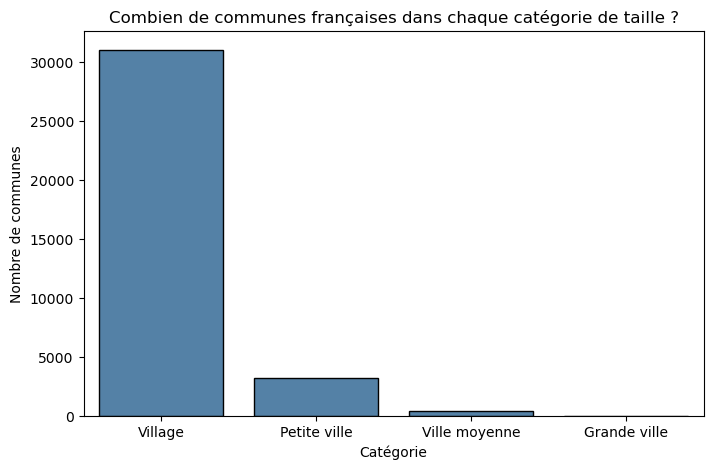

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(data=df, x="taille_ville", color="#4682b4", edgecolor="black", ax=ax)

ax.set_title("Combien de communes françaises dans chaque catégorie de taille ?")
ax.set_xlabel("Catégorie")
ax.set_ylabel("Nombre de communes")

plt.show()

 Boxplots : comparer des distributions

Un **boxplot** (boîte à moustaches) résume une distribution de valeurs en une seule forme :

- la ligne au milieu de la boîte = la **médiane** ;
- la boîte = les 50 % de valeurs centrales (entre le 1er et le 3e quartile) ;
- les moustaches = l'essentiel du reste des valeurs ;
- les points isolés = des valeurs exceptionnelles (des "outliers").

C'est très utile pour **comparer plusieurs groupes d'un coup d'œil** — ici, la dispersion de la population selon la catégorie de taille de ville.

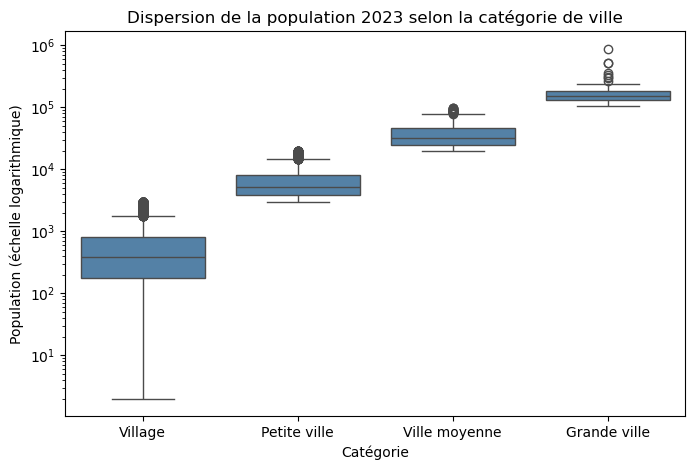

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="taille_ville",
    y="PMUN2023_num",
    color="#4682b4",
    ax=ax,
)

# La population varie énormément (de quelques habitants à plus de 2 millions) :
# on passe l'axe Y en échelle logarithmique pour que le graphique reste lisible.
ax.set_yscale("log")

ax.set_title("Dispersion de la population 2023 selon la catégorie de ville")
ax.set_xlabel("Catégorie")
ax.set_ylabel("Population (échelle logarithmique)")

plt.show()

*On voit que la catégorie "Village" est resserrée (toutes les valeurs sont proches), alors que "Grande ville" est beaucoup plus étalée : elle contient aussi bien des villes de 20 000 habitants que Paris.*

### Exercice 3

Réalisez un boxplot comparant la population des communes (`PMUN2023_num`, en échelle log) selon la **région** (colonne `REG`), pour les 3 ou 4 régions de votre choix (filtrez `df` avec `df["REG"].isin([...])` avant de tracer le graphique).

In [42]:
# Votre code ici

## Histogramme : à quoi ressemble la distribution des tailles de villes ?

Un **histogramme** découpe une variable numérique en tranches régulières et compte combien de communes tombent dans chaque tranche. C'est différent du diagramme en barres de la Partie 3 (qui comparait des villes précises) : ici, on regarde la **forme globale** de la distribution, sur toutes les communes de France à la fois.

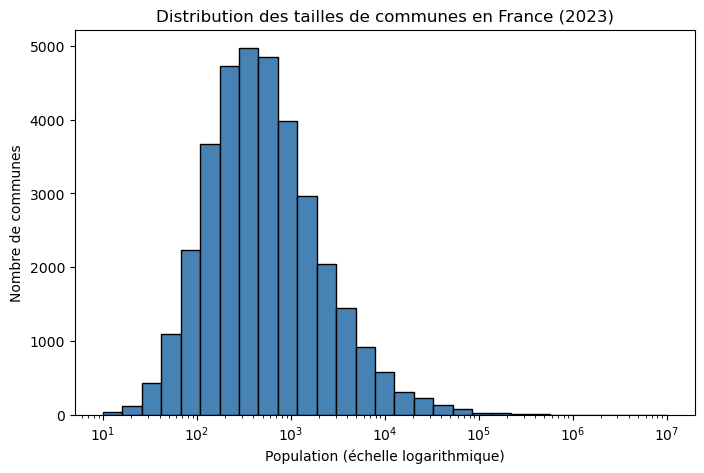

In [43]:
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))

# On utilise des tranches espacées de façon logarithmique, car les tailles de
# ville s'étendent sur plusieurs ordres de grandeur (de 10 à plus de 2 millions)
tranches = np.logspace(1, 7, 30)

ax.hist(df["PMUN2023_num"], bins=tranches, color="#4682b4", edgecolor="black")
ax.set_xscale("log")

ax.set_title("Distribution des tailles de communes en France (2023)")
ax.set_xlabel("Population (échelle logarithmique)")
ax.set_ylabel("Nombre de communes")

plt.show()

*On retrouve un phénomène bien connu des géographes et démographes : l'écrasante majorité des communes sont petites, et seule une poignée de très grandes villes concentre une grande partie de la population (loi rang-taille / loi de Zipf).*

## Heatmap : croiser deux variables catégorielles

Une **heatmap** (carte de chaleur) affiche un tableau croisé sous forme de couleurs : plus une case est foncée, plus la valeur est élevée. C'est pratique pour repérer d'un coup d'œil où se concentrent les effectifs entre deux catégories — ici, le département et la catégorie de taille de ville.

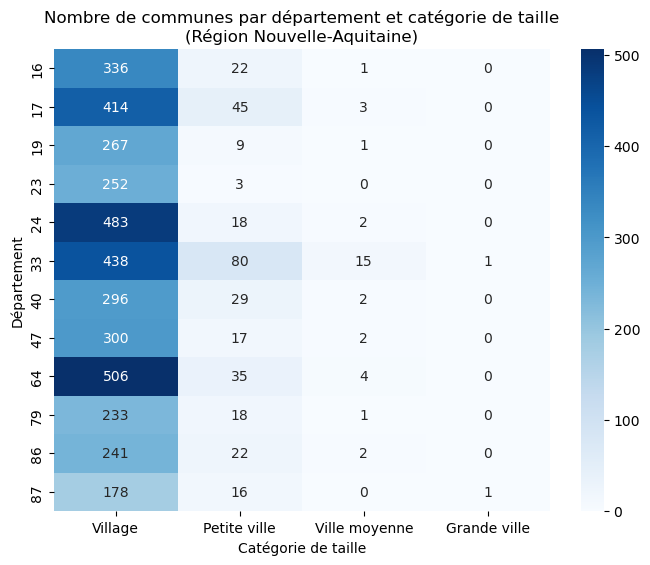

In [44]:
# On se limite à la région Nouvelle-Aquitaine (code REG "75") pour garder un
# tableau lisible (12 départements)
df_na = df[df["REG"] == "75"]

# Tableau croisé : nombre de communes par département et par catégorie de taille
tableau_croise = pd.crosstab(df_na["DEP"], df_na["taille_ville"])

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(tableau_croise, annot=True, fmt="d", cmap="Blues", ax=ax)

ax.set_title("Nombre de communes par département et catégorie de taille\n(Région Nouvelle-Aquitaine)")
ax.set_xlabel("Catégorie de taille")
ax.set_ylabel("Département")

plt.show()

##  Bonus : un graphique dynamique avec Plotly

Tous les graphiques précédents sont **statiques** : une fois affichés, on ne peut plus zoomer ni consulter la valeur exacte d'un point. La bibliothèque **Plotly** permet de créer des graphiques **interactifs**, directement utilisables dans un notebook : on peut zoomer, se déplacer, et survoler un point avec la souris pour voir sa valeur.

*(Si nécessaire : `pip install plotly`. Ce type de graphique fonctionne dans un notebook ou une page web, mais pas dans un document imprimé.)*

In [45]:
import plotly.express as px

fig = px.line(
    df_long,
    x="Annee",
    y="Population",
    color="LIBGEO",
    markers=True,
    title="Évolution démographique interactive (survolez les points, zoomez avec la souris)",
    labels={"Annee": "Année de recensement", "Population": "Nombre d'habitants", "LIBGEO": "Ville"},
)

fig.show()

*Essayez de sélectionner une période avec la souris pour zoomer, ou de survoler un point pour voir l'année et la population exactes.*

# EXERCICE DE SYNTHÈSE (30 minutes)

Vous allez appliquer tout ce que vous avez appris à un **département de votre choix** (colonne `DEP`, par exemple `"87"` pour la Haute-Vienne, `"33"` pour la Gironde...).

**Étapes :**

1. Filtrez `df` pour ne garder que les communes de votre département (`df[df["DEP"] == "87"]`).
2. Reprenez la même discrétisation qu'en Partie 4 (`pd.cut()` sur `PMUN2023_num`) pour classer les communes de ce département par taille.
3. Produisez une figure **à deux axes côte à côte** (`plt.subplots(1, 2)`) :
   - **Axe de gauche** : un `sns.countplot()` du nombre de communes par catégorie de taille, pour votre département ;
   - **Axe de droite** : un `sns.boxplot()` croisant la catégorie de taille avec l'évolution de la population entre 1876 et 2023 (vous pouvez calculer une nouvelle colonne `evolution = PMUN2023_num - PTOT1876_num`, en nettoyant `PTOT1876` de la même façon que `PMUN2023`).
4. **Pour aller plus loin (facultatif)** : ajoutez un histogramme de la population 2023 de votre département, ou reprenez le graphique Plotly de la Partie 8 pour explorer interactivement les communes de votre département.

In [46]:
# Votre code ici